<a href="https://colab.research.google.com/github/Sujitramanoharan/Gesture-Recognition/blob/main/GESTURE_FINAL_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install lime -q

print(" Libraries installed!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Libraries installed!


In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      Dropout, BatchNormalization, Rescaling)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score,
                              precision_score, recall_score)
from scipy.stats import entropy as scipy_entropy

print("TF Version :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TF Version : 2.19.0
GPU        : []


In [ ]:
DATASET_PATH = '/content/drive/MyDrive/leapGestRecog'
IMG_SIZE     = 64
BATCH_SIZE   = 32
EPOCHS       = 25
SEED         = 42

gesture_commands = {
    '01_palm':       'STOP',
    '02_l':          'TURN LEFT',
    '03_fist':       'EMERGENCY HALT',
    '04_fist_moved': 'MOVE FORWARD',
    '05_thumb':      'CONFIRM',
    '06_index':      'TURN RIGHT',
    '07_ok':         'TASK COMPLETE',
    '08_palm_moved': 'SLOW DOWN',
    '09_c':          'SCAN AREA',
    '10_down':       'DESCEND'
}

priority_commands = {
    'STOP':           'CRITICAL',
    'EMERGENCY HALT': 'CRITICAL',
    'MOVE FORWARD':   'PRIMARY',
    'TURN LEFT':      'PRIMARY',
    'TURN RIGHT':     'PRIMARY',
    'CONFIRM':        'PRIMARY',
    'SLOW DOWN':      'SECONDARY',
    'TASK COMPLETE':  'SECONDARY',
    'SCAN AREA':      'EXTENDED',
    'DESCEND':        'EXTENDED'
}

print(" Configuration ready!")
for k, v in gesture_commands.items():
    print(f"   {k:20s} → {v}")

 Configuration ready!
   01_palm              → STOP
   02_l                 → TURN LEFT
   03_fist              → EMERGENCY HALT
   04_fist_moved        → MOVE FORWARD
   05_thumb             → CONFIRM
   06_index             → TURN RIGHT
   07_ok                → TASK COMPLETE
   08_palm_moved        → SLOW DOWN
   09_c                 → SCAN AREA
   10_down              → DESCEND


In [ ]:
images = []
labels = []

print("Loading dataset...")
for subject in sorted(os.listdir(DATASET_PATH)):
    subject_path = os.path.join(DATASET_PATH, subject)
    if not os.path.isdir(subject_path):
        continue
    for gesture in sorted(os.listdir(subject_path)):
        gesture_path = os.path.join(subject_path, gesture)
        if not os.path.isdir(gesture_path):
            continue
        for img_file in sorted(os.listdir(gesture_path)):
            img_path = os.path.join(gesture_path, img_file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img     = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
                images.append(img_rgb)
                labels.append(gesture)

images = np.array(images, dtype='float32') / 255.0
labels = np.array(labels)

le             = LabelEncoder()
labels_encoded = le.fit_transform(labels)
labels_cat     = to_categorical(labels_encoded)
NUM_CLASSES    = len(le.classes_)

print(f"\n Total images : {len(images)}")
print(f" Classes      : {NUM_CLASSES}")
print(f" Image shape  : {images[0].shape}")
print("\nClasses found:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls} → {gesture_commands[cls]}")

Loading dataset...

 Total images : 20000
 Classes      : 10
 Image shape  : (64, 64, 3)

Classes found:
  0: 01_palm → STOP
  1: 02_l → TURN LEFT
  2: 03_fist → EMERGENCY HALT
  3: 04_fist_moved → MOVE FORWARD
  4: 05_thumb → CONFIRM
  5: 06_index → TURN RIGHT
  6: 07_ok → TASK COMPLETE
  7: 08_palm_moved → SLOW DOWN
  8: 09_c → SCAN AREA
  9: 10_down → DESCEND


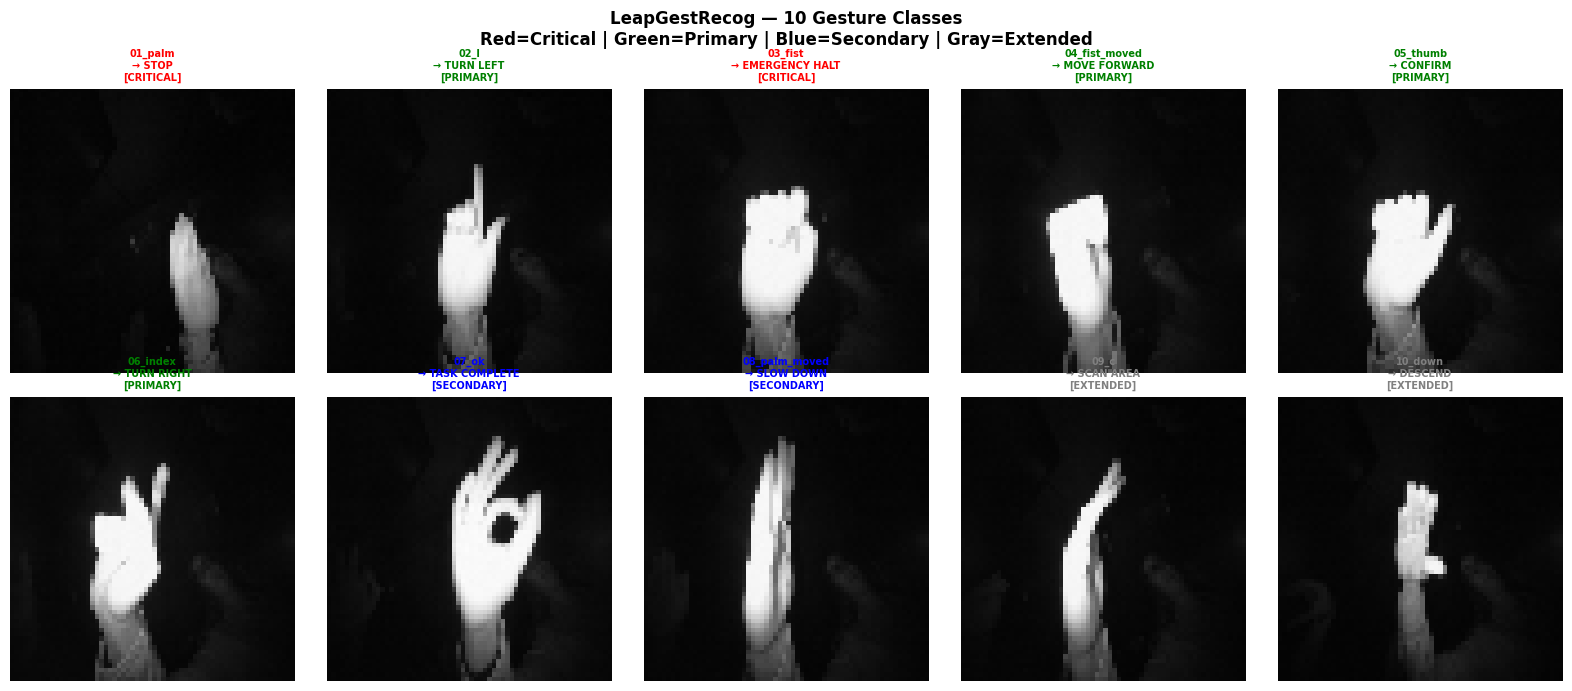

 Dataset visualization saved!


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for i, cls in enumerate(le.classes_):
    idx = np.where(labels == cls)[0][0]
    axes[i//5, i%5].imshow(images[idx])
    cmd = gesture_commands[cls]
    pri = priority_commands[cmd]
    color = 'red' if pri == 'CRITICAL' else \
            'green' if pri == 'PRIMARY' else \
            'blue' if pri == 'SECONDARY' else 'gray'
    axes[i//5, i%5].set_title(
        f"{cls}\n→ {cmd}\n[{pri}]",
        fontsize=7, color=color, fontweight='bold')
    axes[i//5, i%5].axis('off')

plt.suptitle(
    'LeapGestRecog — 10 Gesture Classes\n'
    'Red=Critical | Green=Primary | Blue=Secondary | Gray=Extended',
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150)
plt.show()
print(" Dataset visualization saved!")

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels_cat,
    test_size=0.3,
    random_state=SEED,
    stratify=labels_cat)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=SEED,
    stratify=y_temp)

print(f" Train      : {X_train.shape[0]} images")
print(f" Validation : {X_val.shape[0]} images")
print(f" Test       : {X_test.shape[0]} images")

 Train      : 14000 images
 Validation : 3000 images
 Test       : 3000 images


In [ ]:
def build_mobilenet(num_classes):
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False   # Freeze entire base

    x      = GlobalAveragePooling2D()(base.output)
    x      = BatchNormalization()(x)
    x      = Dense(256, activation='relu')(x)
    x      = Dropout(0.5)(x)
    x      = Dense(128, activation='relu')(x)
    x      = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model  = Model(inputs=base.input, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

callbacks_mobile = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1),
    ModelCheckpoint(
        'mobilenet_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=0)
]

mobilenet_model = build_mobilenet(NUM_CLASSES)
print(f"MobileNetV2 parameters: {mobilenet_model.count_params():,}")
print("\n=== Training MobileNetV2 ===")

#  Direct fit — NO datagen.flow()
history_mobile = mobilenet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_mobile,
    verbose=1)

print("\n MobileNetV2 Training Complete!")

MobileNetV2 parameters: 2,625,226

=== Training MobileNetV2 ===
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 91s 189ms/step - accuracy: 0.5426 - loss: 1.4051 - val_accuracy: 0.9500 - val_loss: 0.3754
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 71s 163ms/step - accuracy: 0.8636 - loss: 0.4661 - val_accuracy: 0.9887 - val_loss: 0.0927
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 86s 173ms/step - accuracy: 0.9348 - loss: 0.2326 - val_accuracy: 0.9950 - val_loss: 0.0352
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 70s 159ms/step - accuracy: 0.9606 - loss: 0.1392 - val_accuracy: 0.9977 - val_loss: 0.0169
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 77s 177ms/step - accuracy: 0.9743 - loss: 0.0963 - val_accuracy: 0.9980 - val_loss: 0.0106
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 74s 170ms/step - accuracy: 0.9806 - loss: 0.0696 - val_accuracy: 0.9990 - val_loss: 0.0073
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 71s 162ms/step - accuracy: 0.9851 - loss: 0.0544 - val_accuracy: 0.9997 - val_loss: 0.0051
Epoch 8/25
438/438 

In [ ]:
#  Stage 2: Unfreeze top 30 layers for fine-tuning
print("=== Stage 2: Fine-tuning MobileNetV2 top layers ===")

# Unfreeze top 30 layers of MobileNetV2 base
for layer in mobilenet_model.layers:
    if hasattr(layer, 'layers'):          # This is the base model
        total = len(layer.layers)
        for sublayer in layer.layers[total-30:]:
            sublayer.trainable = True

# Recompile with lower learning rate
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

callbacks_ft = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1),
    ModelCheckpoint(
        'mobilenet_finetuned.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=0)
]

history_mobile_ft = mobilenet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_ft,
    verbose=1)

print("\n MobileNetV2 Fine-tuning Complete!")

=== Stage 2: Fine-tuning MobileNetV2 top layers ===
Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 92s 191ms/step - accuracy: 0.9883 - loss: 0.0441 - val_accuracy: 0.9997 - val_loss: 0.0049
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 131s 165ms/step - accuracy: 0.9895 - loss: 0.0397 - val_accuracy: 0.9997 - val_loss: 0.0048
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 71s 162ms/step - accuracy: 0.9893 - loss: 0.0400 - val_accuracy: 0.9997 - val_loss: 0.0046
Epoch 4/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 73s 166ms/step - accuracy: 0.9912 - loss: 0.0371 - val_accuracy: 0.9997 - val_loss: 0.0044
Epoch 5/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 81s 165ms/step - accuracy: 0.9914 - loss: 0.0349 - val_accuracy: 0.9997 - val_loss: 0.0043
Epoch 6/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 71s 161ms/step - accuracy: 0.9901 - loss: 0.0349 - val_accuracy: 0.9997 - val_loss: 0.0040
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

 MobileNetV2 Fine-tuning Complete!


In [ ]:
def build_efficientnet(num_classes):
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x      = Rescaling(scale=255.0)(inputs)

    base   = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False

    x      = base(x)
    x      = GlobalAveragePooling2D()(x)
    x      = BatchNormalization()(x)
    x      = Dense(256, activation='relu')(x)
    x      = Dropout(0.5)(x)
    x      = Dense(128, activation='relu')(x)
    x      = Dropout(0.3)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model  = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy'])
    return model

callbacks_eff = [
    EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1),
    ModelCheckpoint(
        'efficientnet_best.keras',
        save_best_only=True,
        monitor='val_accuracy',
        verbose=0)
]

efficientnet_model = build_efficientnet(NUM_CLASSES)
print(f"EfficientNetB0 parameters: {efficientnet_model.count_params():,}")
print("\n=== Training EfficientNetB0 ===")

#  Direct fit — NO datagen.flow()
history_efficient = efficientnet_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_eff,
    verbose=1)

print("\n EfficientNetB0 Training Complete!")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0 parameters: 4,416,813

=== Training EfficientNetB0 ===
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 152s 299ms/step - accuracy: 0.5641 - loss: 1.3417 - val_accuracy: 0.9693 - val_loss: 0.2808
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 114s 261ms/step - accuracy: 0.8659 - loss: 0.4245 - val_accuracy: 0.9927 - val_loss: 0.0448
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 138s 252ms/step - accuracy: 0.9286 - loss: 0.2293 - val_accuracy: 0.9960 - val_loss: 0.0162
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 112s 255ms/step - accuracy: 0.9506 - loss: 0.1619 - val_accuracy: 0.9977 - val_loss: 0.0080
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 111s 252ms/step - accuracy: 0.9634 - loss: 0.1148 - val_accuracy: 0.9993 - val_loss: 0.0043
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 148s 267ms/step - accuracy: 0.9721 - loss: 0.0899 - val_accuracy: 0.9993 - val_loss: 0.0025
Epoch 7/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 114s 260ms/step - accuracy: 0.9780 - loss: 0.07

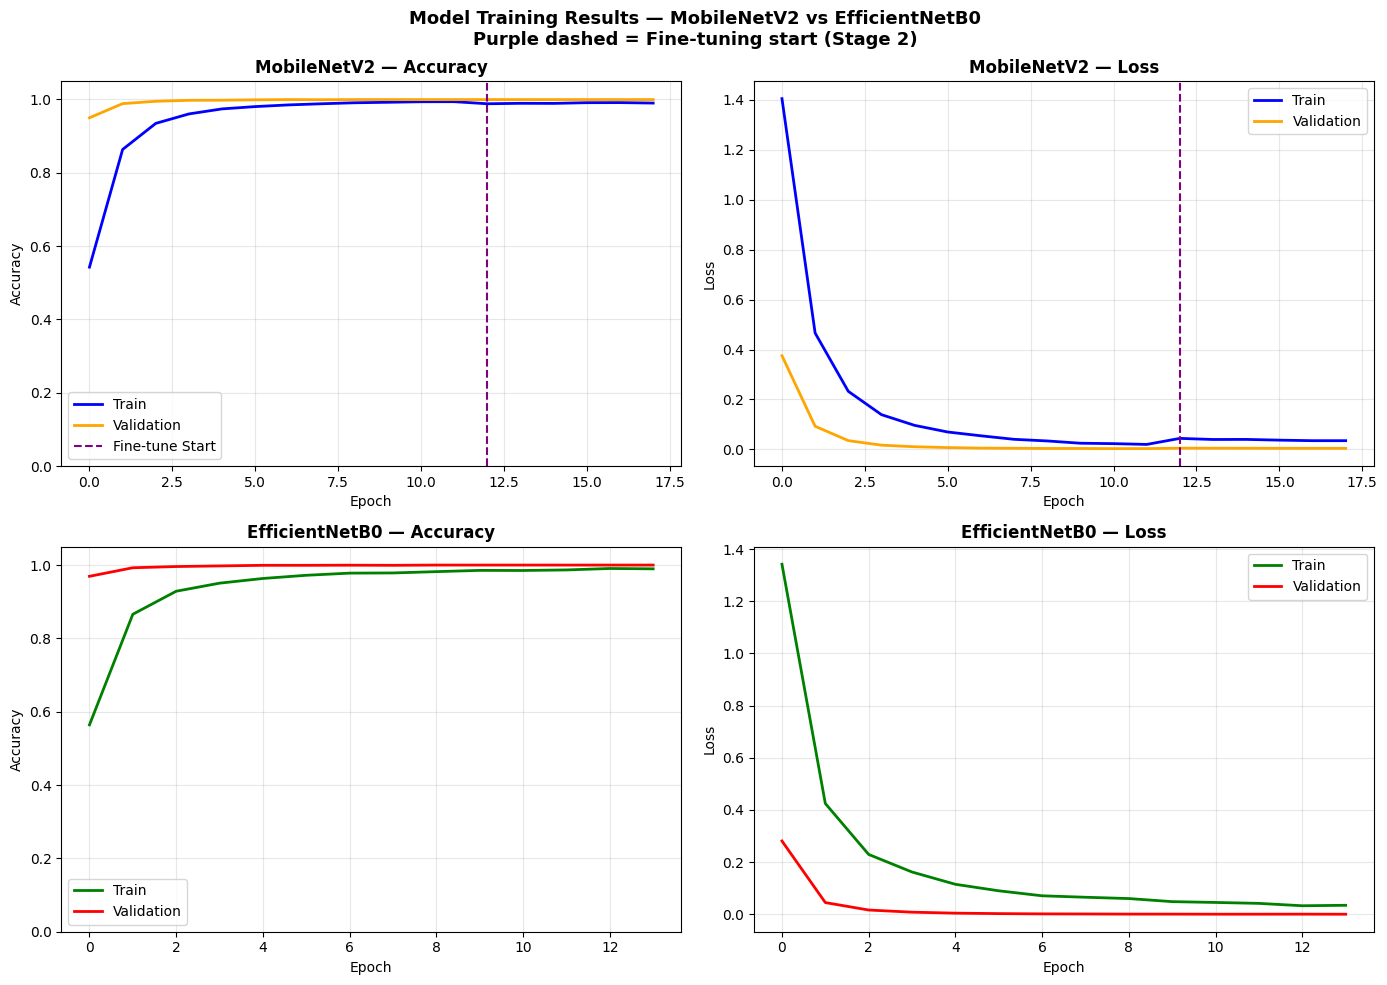

 Training plots saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Combine Stage 1 + Stage 2 for MobileNetV2
acc_m     = (history_mobile.history['accuracy'] +
             history_mobile_ft.history['accuracy'])
val_acc_m = (history_mobile.history['val_accuracy'] +
             history_mobile_ft.history['val_accuracy'])
loss_m    = (history_mobile.history['loss'] +
             history_mobile_ft.history['loss'])
val_loss_m = (history_mobile.history['val_loss'] +
              history_mobile_ft.history['val_loss'])
ft_start  = len(history_mobile.history['accuracy'])

# MobileNetV2 Accuracy
axes[0,0].plot(acc_m,     label='Train',      color='blue',   linewidth=2)
axes[0,0].plot(val_acc_m, label='Validation', color='orange', linewidth=2)
axes[0,0].axvline(x=ft_start, color='purple', linestyle='--',
                  linewidth=1.5, label='Fine-tune Start')
axes[0,0].set_title('MobileNetV2 — Accuracy', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_ylim([0, 1.05])

# MobileNetV2 Loss
axes[0,1].plot(loss_m,    label='Train',      color='blue',   linewidth=2)
axes[0,1].plot(val_loss_m, label='Validation', color='orange', linewidth=2)
axes[0,1].axvline(x=ft_start, color='purple', linestyle='--', linewidth=1.5)
axes[0,1].set_title('MobileNetV2 — Loss', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# EfficientNetB0 Accuracy
axes[1,0].plot(history_efficient.history['accuracy'],
               label='Train',      color='green', linewidth=2)
axes[1,0].plot(history_efficient.history['val_accuracy'],
               label='Validation', color='red',   linewidth=2)
axes[1,0].set_title('EfficientNetB0 — Accuracy', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_ylim([0, 1.05])

# EfficientNetB0 Loss
axes[1,1].plot(history_efficient.history['loss'],
               label='Train',      color='green', linewidth=2)
axes[1,1].plot(history_efficient.history['val_loss'],
               label='Validation', color='red',   linewidth=2)
axes[1,1].set_title('EfficientNetB0 — Loss', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Loss')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.suptitle(
    'Model Training Results — MobileNetV2 vs EfficientNetB0\n'
    'Purple dashed = Fine-tuning start (Stage 2)',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_results.png', dpi=150)
plt.show()
print(" Training plots saved!")

MobileNetV2 — Classification Report
                precision    recall  f1-score   support

          STOP       1.00      1.00      1.00       300
     TURN LEFT       1.00      1.00      1.00       300
EMERGENCY HALT       1.00      1.00      1.00       300
  MOVE FORWARD       1.00      1.00      1.00       300
       CONFIRM       1.00      1.00      1.00       300
    TURN RIGHT       1.00      0.99      1.00       300
 TASK COMPLETE       1.00      1.00      1.00       300
     SLOW DOWN       1.00      1.00      1.00       300
     SCAN AREA       1.00      1.00      1.00       300
       DESCEND       1.00      1.00      1.00       300

      accuracy                           1.00      3000
     macro avg       1.00      1.00      1.00      3000
  weighted avg       1.00      1.00      1.00      3000

EfficientNetB0 — Classification Report
                precision    recall  f1-score   support

          STOP       1.00      1.00      1.00       300
     TURN LEFT       1.00

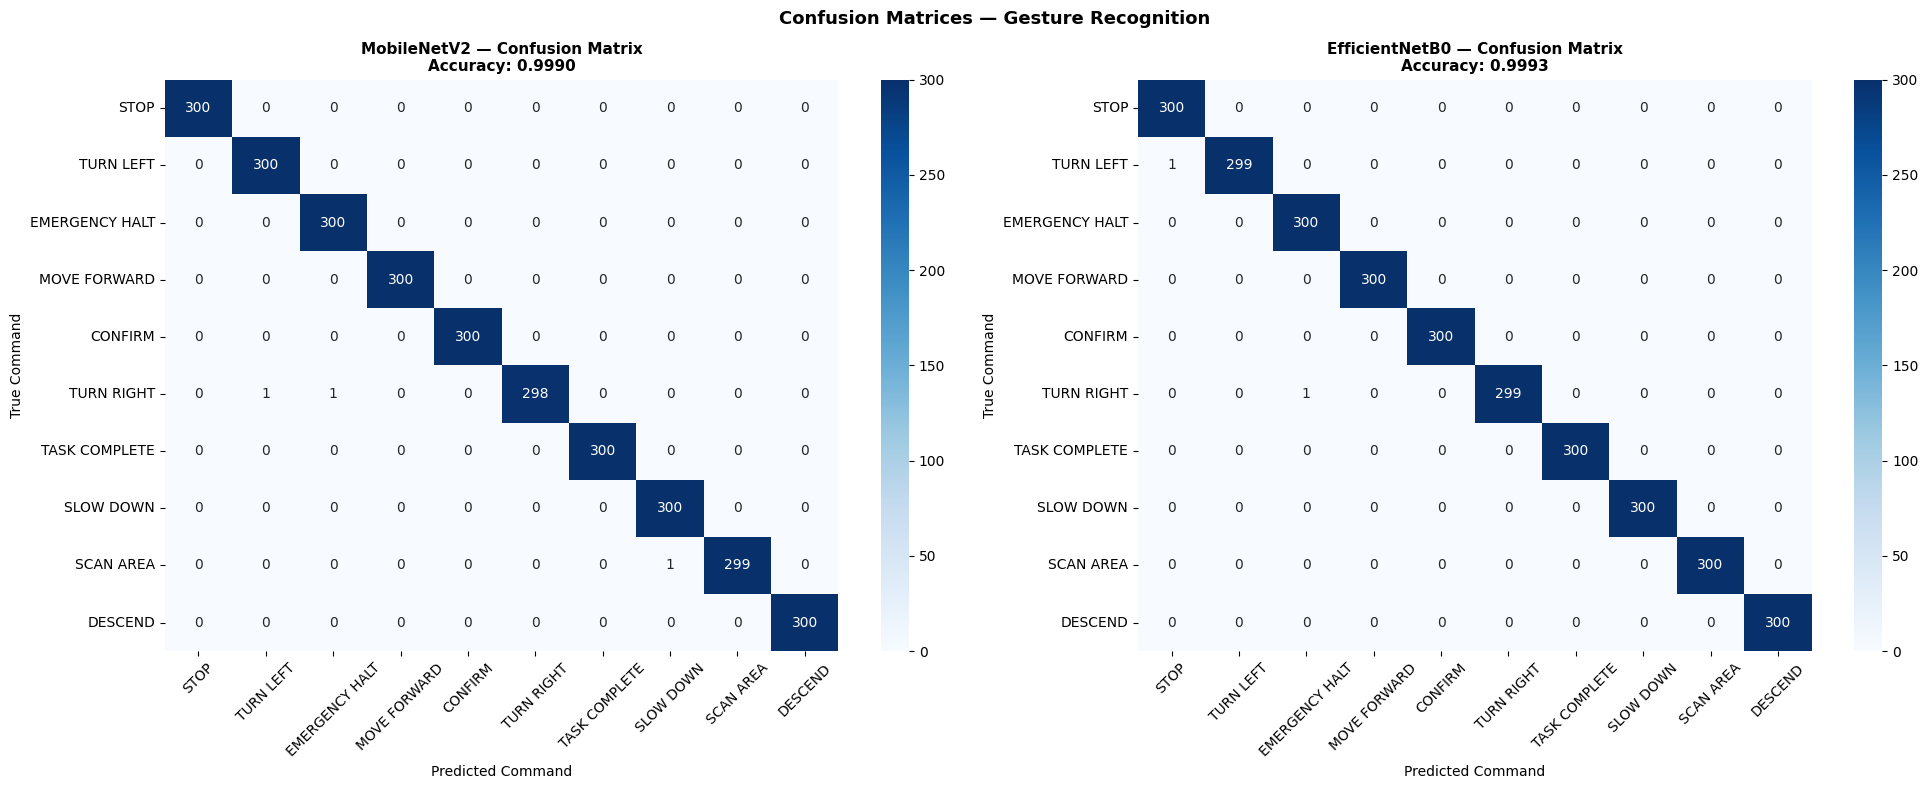

 Evaluation complete!


In [ ]:
y_pred_mobile = np.argmax(
    mobilenet_model.predict(X_test, verbose=0), axis=1)
y_pred_effnet = np.argmax(
    efficientnet_model.predict(X_test, verbose=0), axis=1)
y_true        = np.argmax(y_test, axis=1)
class_names   = [gesture_commands[c] for c in le.classes_]

print("="*55)
print("MobileNetV2 — Classification Report")
print("="*55)
print(classification_report(
    y_true, y_pred_mobile, target_names=class_names))

print("="*55)
print("EfficientNetB0 — Classification Report")
print("="*55)
print(classification_report(
    y_true, y_pred_effnet, target_names=class_names))

# Summary table
summary = {
    'Model':     ['MobileNetV2', 'EfficientNetB0'],
    'Accuracy':  [round(accuracy_score(y_true, y_pred_mobile), 4),
                  round(accuracy_score(y_true, y_pred_effnet),  4)],
    'Precision': [round(precision_score(y_true, y_pred_mobile, average='weighted'), 4),
                  round(precision_score(y_true, y_pred_effnet,  average='weighted'), 4)],
    'Recall':    [round(recall_score(y_true, y_pred_mobile, average='weighted'), 4),
                  round(recall_score(y_true, y_pred_effnet,  average='weighted'), 4)],
    'F1-Score':  [round(f1_score(y_true, y_pred_mobile, average='weighted'), 4),
                  round(f1_score(y_true, y_pred_effnet,  average='weighted'), 4)],
    'Errors':    [int(np.sum(y_pred_mobile != y_true)),
                  int(np.sum(y_pred_effnet  != y_true))]
}
df_summary = pd.DataFrame(summary)
print("\n" + "="*55)
print("MODEL COMPARISON SUMMARY")
print("="*55)
print(df_summary.to_string(index=False))
df_summary.to_csv('model_comparison.csv', index=False)

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, preds, title in zip(
        axes,
        [y_pred_mobile, y_pred_effnet],
        ['MobileNetV2', 'EfficientNetB0']):
    cm  = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names, ax=ax)
    acc = accuracy_score(y_true, preds)
    ax.set_title(f'{title} — Confusion Matrix\nAccuracy: {acc:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Command')
    ax.set_ylabel('True Command')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Confusion Matrices — Gesture Recognition',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(" Evaluation complete!")

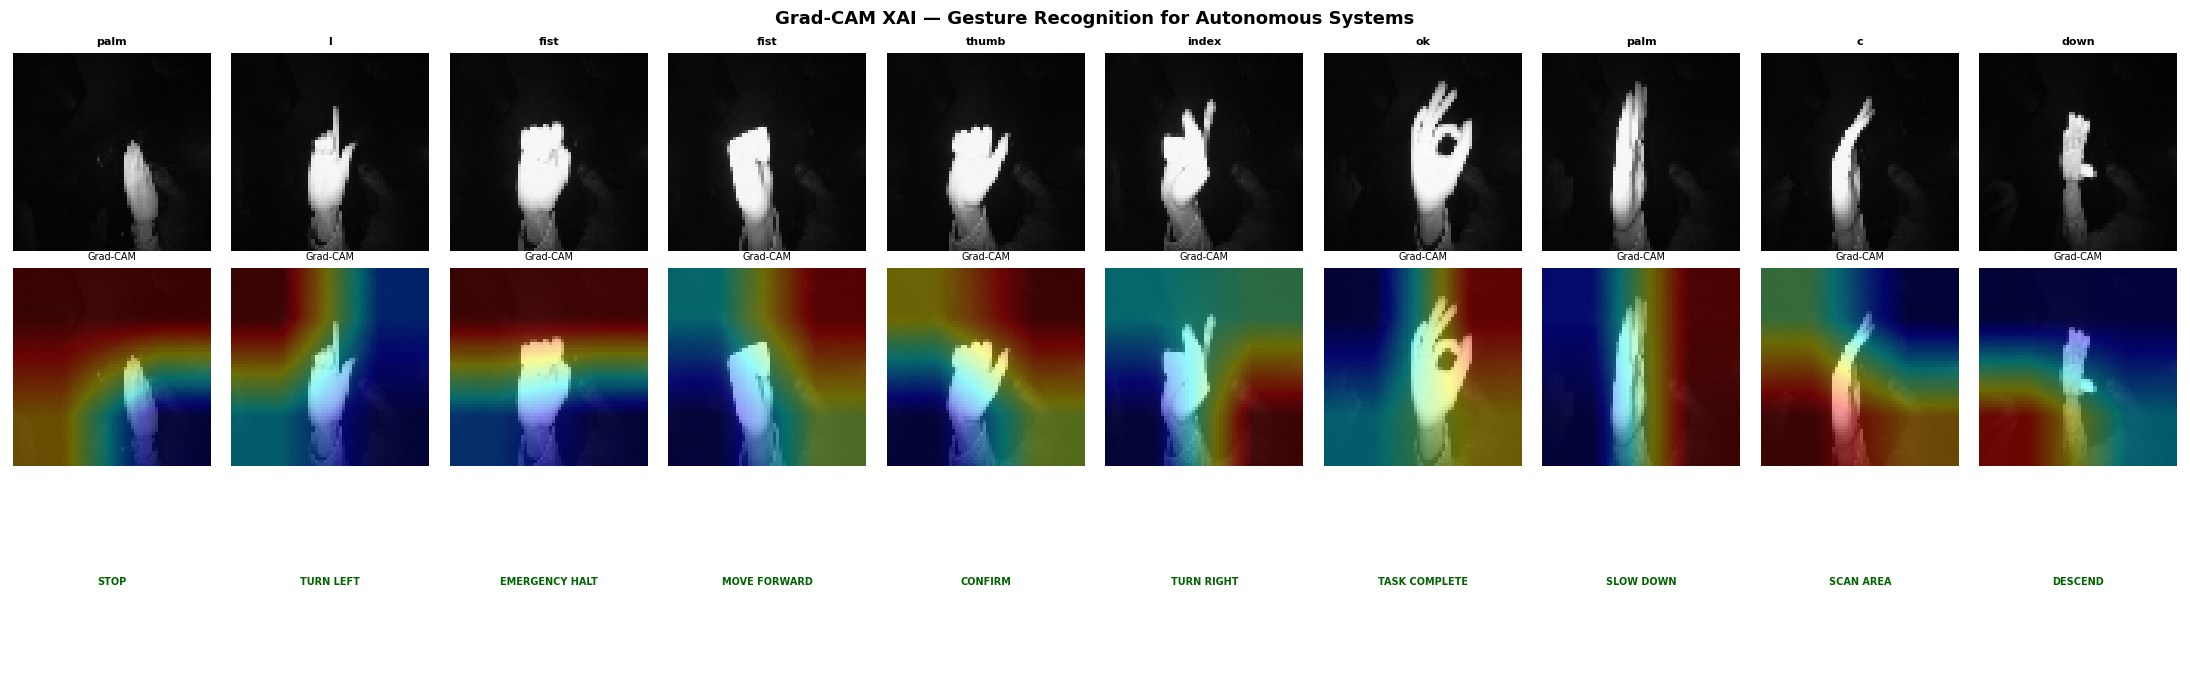

Grad-CAM complete!


In [ ]:
def get_gradcam(model, image, class_idx):
    # Find last conv layer automatically
    last_conv = None
    for layer in reversed(model.layers):
        if 'conv' in layer.name.lower():
            last_conv = layer.name
            break

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv).output, model.output])

    with tf.GradientTape() as tape:
        inputs = tf.cast(image[np.newaxis], tf.float32)
        conv_out, preds = grad_model(inputs)
        loss = preds[:, class_idx]

    grads      = tape.gradient(loss, conv_out)
    pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap    = tf.reduce_mean(tf.multiply(pooled, conv_out[0]), axis=-1)
    heatmap    = tf.maximum(heatmap, 0).numpy()
    heatmap    = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_r  = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    heatmap_c  = cv2.applyColorMap(np.uint8(255*heatmap_r), cv2.COLORMAP_JET)
    overlay    = cv2.addWeighted(
        np.uint8(image*255), 0.6, heatmap_c, 0.4, 0)
    return overlay, heatmap_r

# Plot Grad-CAM for all 10 gestures
fig, axes = plt.subplots(3, 10, figsize=(22, 7))
gradcam_maps = []

for i, cls in enumerate(le.classes_):
    idx       = np.where(labels == cls)[0][0]
    img       = images[idx]
    pred_idx  = np.argmax(mobilenet_model.predict(img[np.newaxis], verbose=0))
    cam, hmap = get_gradcam(mobilenet_model, img, pred_idx)
    gradcam_maps.append(hmap)

    axes[0, i].imshow(img)
    axes[0, i].set_title(cls.split('_')[1], fontsize=8, fontweight='bold')
    axes[0, i].axis('off')

    axes[1, i].imshow(cv2.cvtColor(cam, cv2.COLOR_BGR2RGB))
    axes[1, i].set_title('Grad-CAM', fontsize=7)
    axes[1, i].axis('off')

    axes[2, i].text(0.5, 0.5, gesture_commands[cls],
                    ha='center', va='center', fontsize=7,
                    fontweight='bold', color='darkgreen',
                    transform=axes[2, i].transAxes,
                    wrap=True)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=9)
axes[2, 0].set_ylabel('Command', fontsize=9)

plt.suptitle('Grad-CAM XAI — Gesture Recognition for Autonomous Systems',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gradcam_xai.png', dpi=150)
plt.show()
print("Grad-CAM complete!")

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

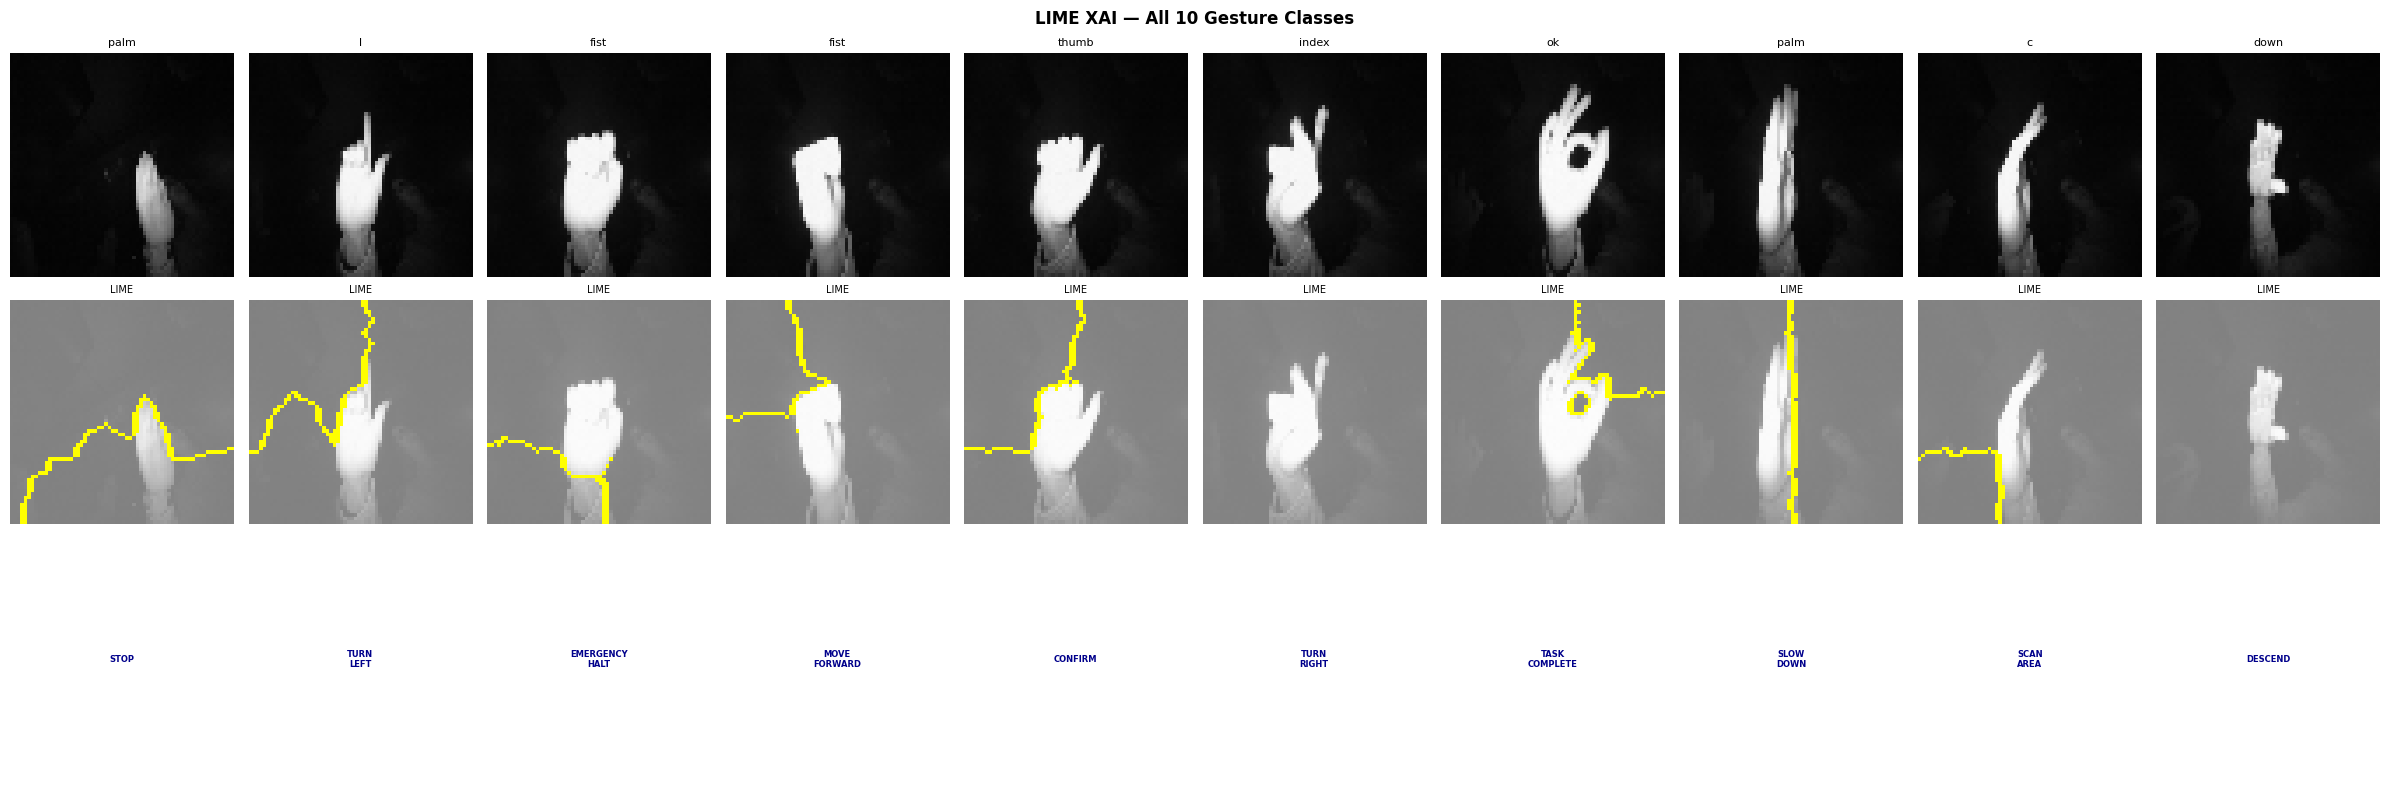

 LIME complete — all 10 classes!


In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()
lime_maps      = []

fig, axes = plt.subplots(3, 10, figsize=(24, 8))

for i, cls in enumerate(le.classes_):
    idx = np.where(labels == cls)[0][0]
    img = images[idx]
    explanation = lime_explainer.explain_instance(
        img.astype('double'),
        lambda x: mobilenet_model.predict(
            x.astype('float32'), verbose=0),
        top_labels=1,
        hide_color=0,
        num_samples=200)
    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False)
    lime_img = mark_boundaries(temp/2 + 0.5, mask)
    lime_maps.append(mask.astype(float))

    axes[0,i].imshow(img, cmap='gray')
    axes[0,i].set_title(cls.split('_')[1], fontsize=8)
    axes[0,i].axis('off')
    axes[1,i].imshow(lime_img)
    axes[1,i].set_title('LIME', fontsize=7)
    axes[1,i].axis('off')
    axes[2,i].text(0.5, 0.5,
                   gesture_commands[cls].replace(' ', '\n'),
                   ha='center', va='center', fontsize=6,
                   fontweight='bold', color='darkblue',
                   transform=axes[2,i].transAxes)
    axes[2,i].axis('off')

axes[0,0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1,0].set_ylabel('LIME',     fontsize=9, fontweight='bold')
axes[2,0].set_ylabel('Command',  fontsize=9, fontweight='bold')
plt.suptitle('LIME XAI — All 10 Gesture Classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('lime_xai.png', dpi=150)
plt.show()
print(" LIME complete — all 10 classes!")

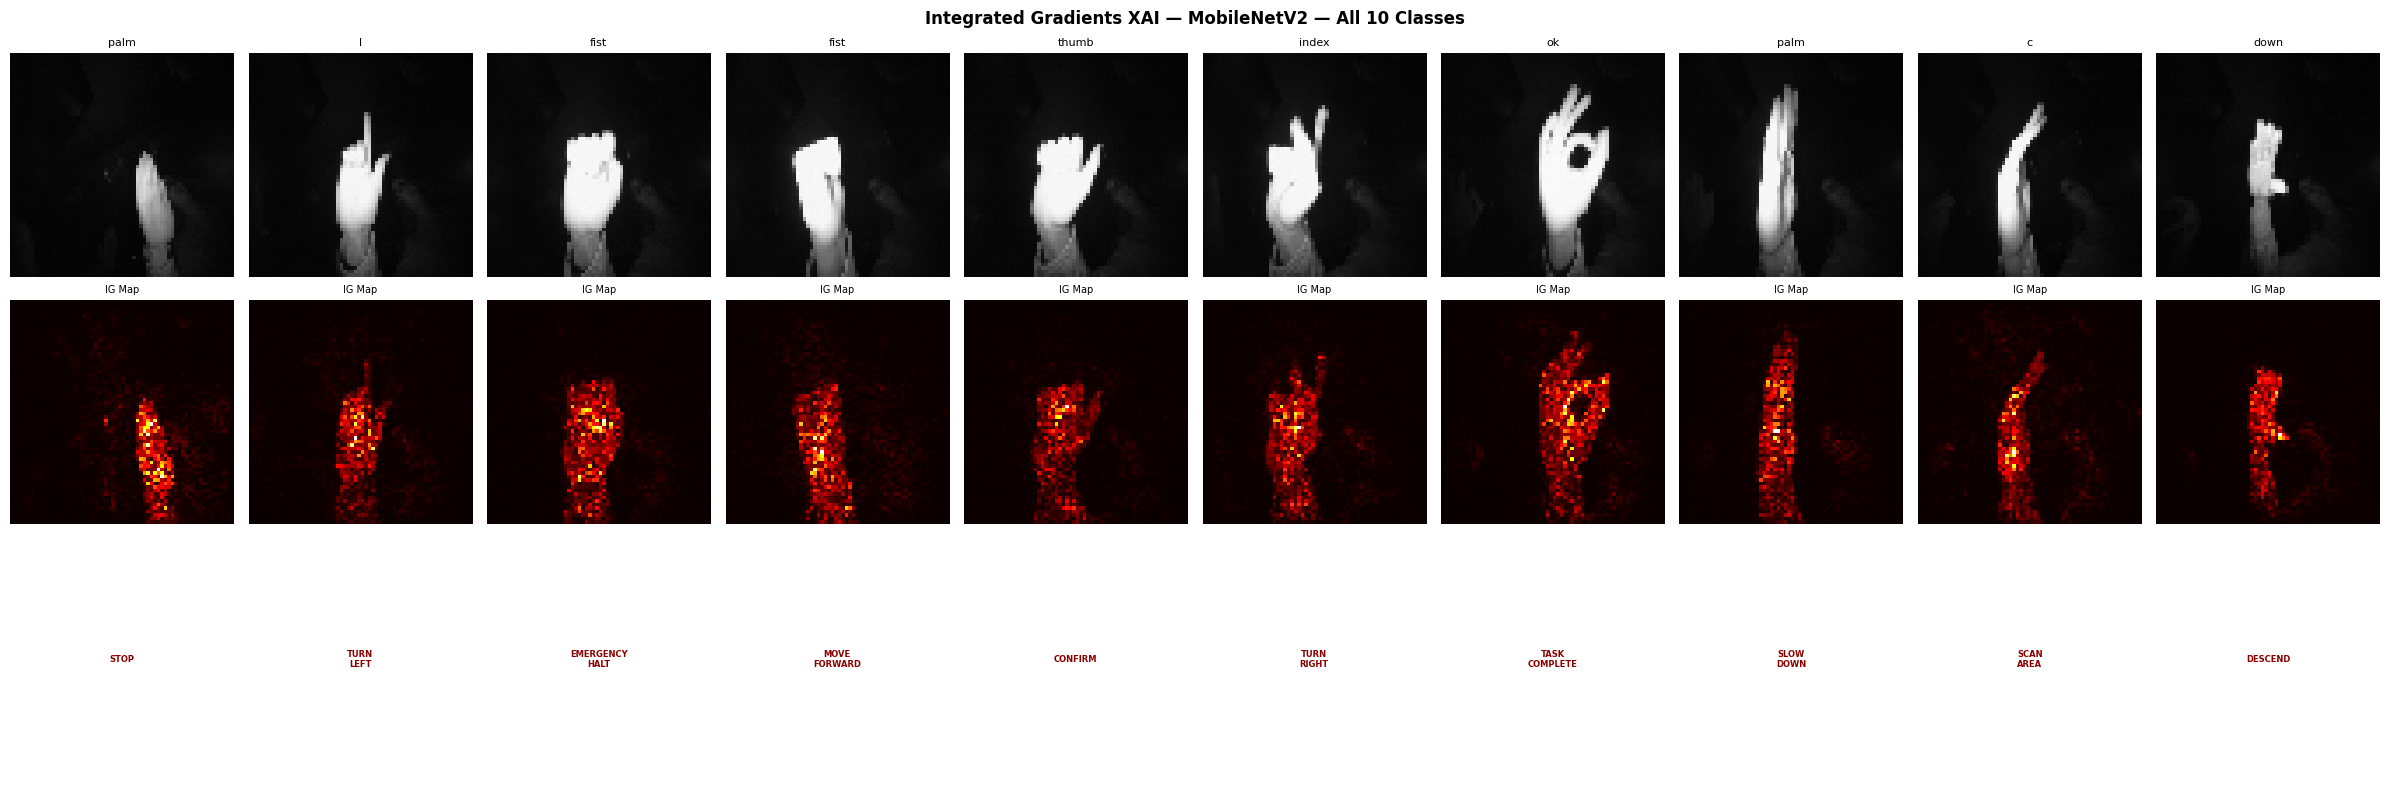

 Integrated Gradients complete!


In [ ]:
ig_maps = []

def integrated_gradients(model, image, class_idx, steps=50):
    baseline  = np.zeros_like(image)
    alphas    = np.linspace(0, 1, steps)
    interp    = np.array([baseline + a*(image - baseline)
                          for a in alphas])
    inputs_tf = tf.cast(interp, tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(inputs_tf)
        preds  = model(inputs_tf)
        target = preds[:, class_idx]
    grads     = tape.gradient(target, inputs_tf).numpy()
    avg_grads = np.mean(grads, axis=0)
    ig        = (image - baseline) * avg_grads
    ig_map    = np.sum(np.abs(ig), axis=-1)
    ig_map    = (ig_map - ig_map.min()) / \
                (ig_map.max() - ig_map.min() + 1e-8)
    return ig_map

fig, axes = plt.subplots(3, 10, figsize=(24, 8))
for i, cls in enumerate(le.classes_):
    idx      = np.where(labels == cls)[0][0]
    img      = images[idx]
    pred_idx = np.argmax(
        mobilenet_model.predict(img[np.newaxis], verbose=0))
    ig_map   = integrated_gradients(mobilenet_model, img, pred_idx)
    ig_maps.append(ig_map)
    axes[0,i].imshow(img, cmap='gray')
    axes[0,i].set_title(cls.split('_')[1], fontsize=8)
    axes[0,i].axis('off')
    axes[1,i].imshow(ig_map, cmap='hot')
    axes[1,i].set_title('IG Map', fontsize=7)
    axes[1,i].axis('off')
    axes[2,i].text(0.5, 0.5,
                   gesture_commands[cls].replace(' ', '\n'),
                   ha='center', va='center', fontsize=6,
                   fontweight='bold', color='darkred',
                   transform=axes[2,i].transAxes)
    axes[2,i].axis('off')

axes[0,0].set_ylabel('Original', fontsize=9, fontweight='bold')
axes[1,0].set_ylabel('IG Map',   fontsize=9, fontweight='bold')
axes[2,0].set_ylabel('Command',  fontsize=9, fontweight='bold')
plt.suptitle('Integrated Gradients XAI — MobileNetV2 — All 10 Classes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ig_mobilenet.png', dpi=150)
plt.show()
print(" Integrated Gradients complete!")


   XAI QUANTITATIVE EVALUATION
          XAI Method  Top-5%  Top-10%  Top-20%  Entropy
            Grad-CAM   0.101    0.200    0.377    8.068
                LIME   0.073    0.146    0.292    8.002
Integrated Gradients   0.549    0.732    0.851    6.863


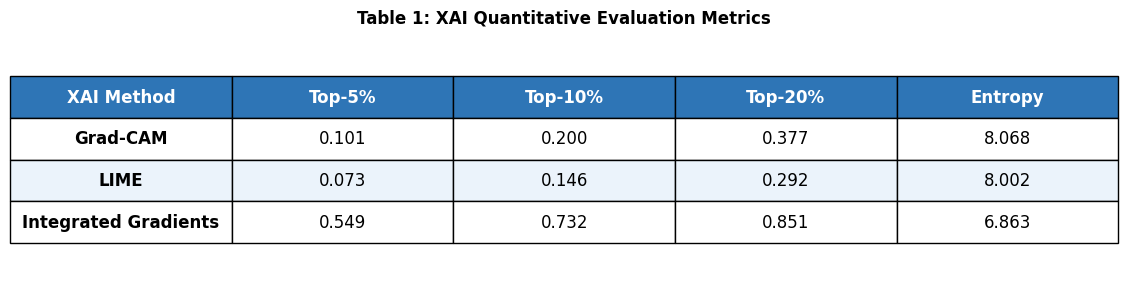

 XAI Metrics table saved!


In [ ]:
def energy_concentration(hmap, p):
    flat        = hmap.flatten()
    sorted_flat = np.sort(flat)[::-1]
    top_k       = int(len(flat) * p)
    return np.sum(sorted_flat[:top_k]) / (np.sum(sorted_flat) + 1e-8)

def map_entropy(hmap):
    flat = hmap.flatten()
    flat = flat / (flat.sum() + 1e-8)
    return scipy_entropy(flat + 1e-8)

methods  = ['Grad-CAM', 'LIME', 'Integrated Gradients']
all_maps = [gradcam_maps, lime_maps, ig_maps]
results  = {'XAI Method':[], 'Top-5%':[], 'Top-10%':[], 'Top-20%':[], 'Entropy':[]}

for name, maps in zip(methods, all_maps):
    results['XAI Method'].append(name)
    results['Top-5%'].append(
        round(float(np.mean([energy_concentration(h,0.05) for h in maps])), 3))
    results['Top-10%'].append(
        round(float(np.mean([energy_concentration(h,0.10) for h in maps])), 3))
    results['Top-20%'].append(
        round(float(np.mean([energy_concentration(h,0.20) for h in maps])), 3))
    results['Entropy'].append(
        round(float(np.mean([map_entropy(h) for h in maps])), 3))

df_metrics = pd.DataFrame(results)
print("\n" + "="*60)
print("   XAI QUANTITATIVE EVALUATION")
print("="*60)
print(df_metrics.to_string(index=False))
df_metrics.to_csv('xai_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 3))
ax.axis('off')
cell_data = [[r[0]] + [f"{float(v):.3f}" for v in r[1:]]
             for r in df_metrics.values.tolist()]
table = ax.table(
    cellText=cell_data,
    colLabels=df_metrics.columns,
    cellLoc='center', loc='center',
    colColours=['#2E75B6'] * 5)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.3, 2.5)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 0:
        cell.set_text_props(fontweight='bold')
    if row % 2 == 0 and row > 0:
        cell.set_facecolor('#EBF3FB')
plt.title('Table 1: XAI Quantitative Evaluation Metrics',
          fontsize=12, fontweight='bold', pad=15)
plt.savefig('xai_metrics_table.png', dpi=150, bbox_inches='tight')
plt.show()
print(" XAI Metrics table saved!")

In [ ]:
import time

print("Converting MobileNetV2 to TFLite...")
converter          = tf.lite.TFLiteConverter.from_keras_model(mobilenet_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model       = converter.convert()
with open('mobilenet_gesture.tflite', 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize('mobilenet_gesture.tflite') / 1024
print(f" TFLite model size: {size_kb:.1f} KB")

interpreter = tf.lite.Interpreter(
    model_path='mobilenet_gesture.tflite')
interpreter.allocate_tensors()
input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

test_img = X_test[0:1].astype(np.float32)
times    = []
for _ in range(100):
    t0 = time.time()
    interpreter.set_tensor(input_details[0]['index'], test_img)
    interpreter.invoke()
    times.append((time.time() - t0) * 1000)

avg_ms = np.mean(times)
fps    = 1000 / avg_ms
print(f" Avg latency  : {avg_ms:.2f} ms/frame")
print(f" Throughput   : {fps:.1f} FPS")
print(f" Edge ready   : {'YES ' if fps > 15 else 'NEEDS OPTIMIZATION'}")

Converting MobileNetV2 to TFLite...
Saved artifact at '/tmp/tmpg9l1kfw_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  137155988626832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988627984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988628368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988627600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988626640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988628176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988628560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988629328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988628944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137155988625872: TensorSpec(shape=(), dtype=tf.re

Running Autonomous Command Demo...


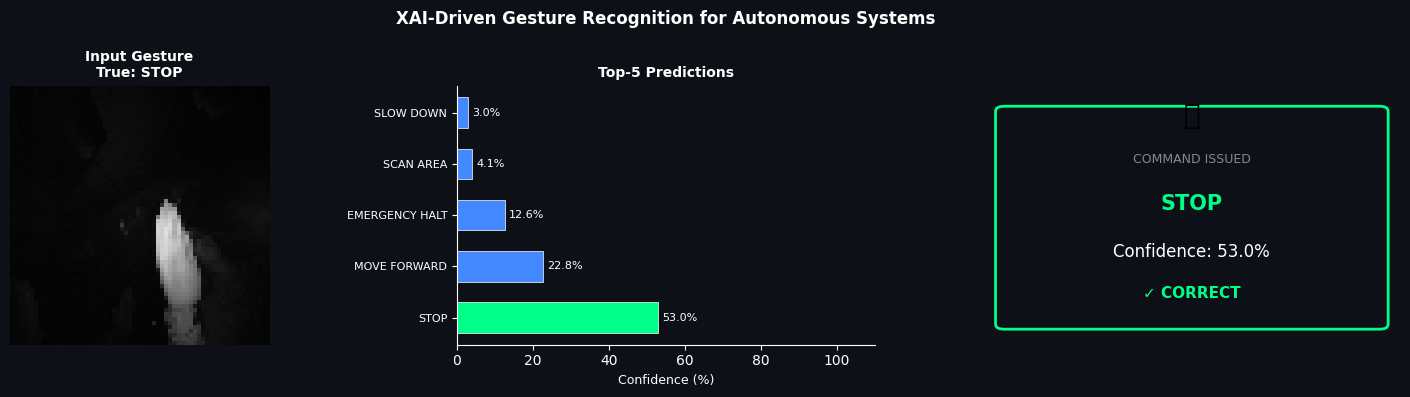

  01_palm → STOP | 53.0% | ✓ CORRECT


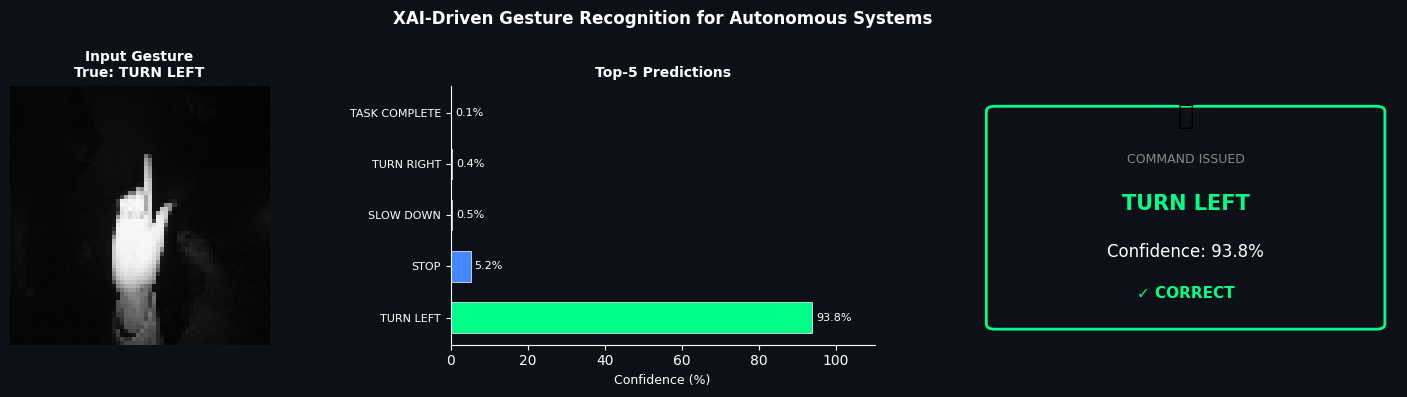

  02_l → TURN LEFT | 93.8% | ✓ CORRECT


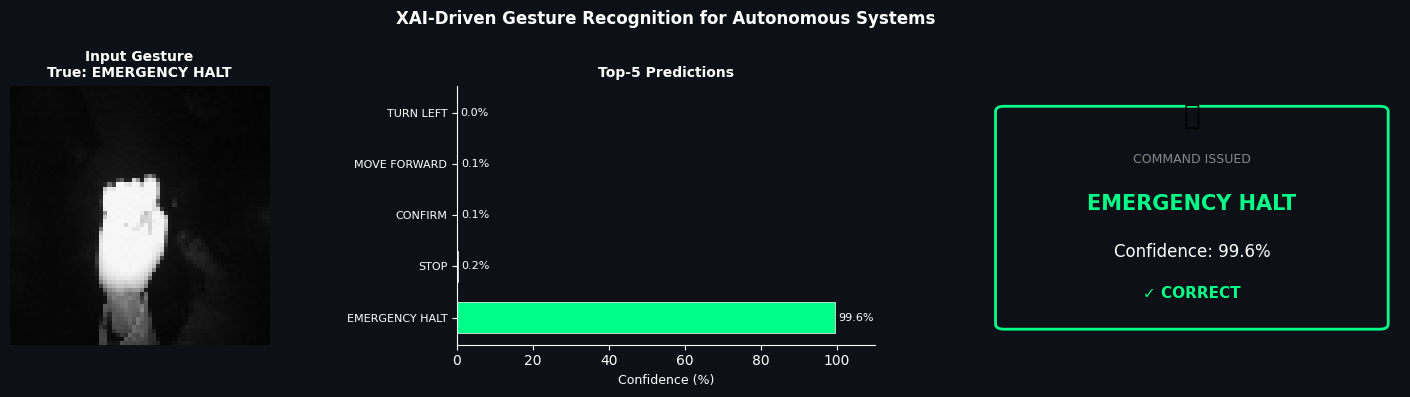

  03_fist → EMERGENCY HALT | 99.6% | ✓ CORRECT


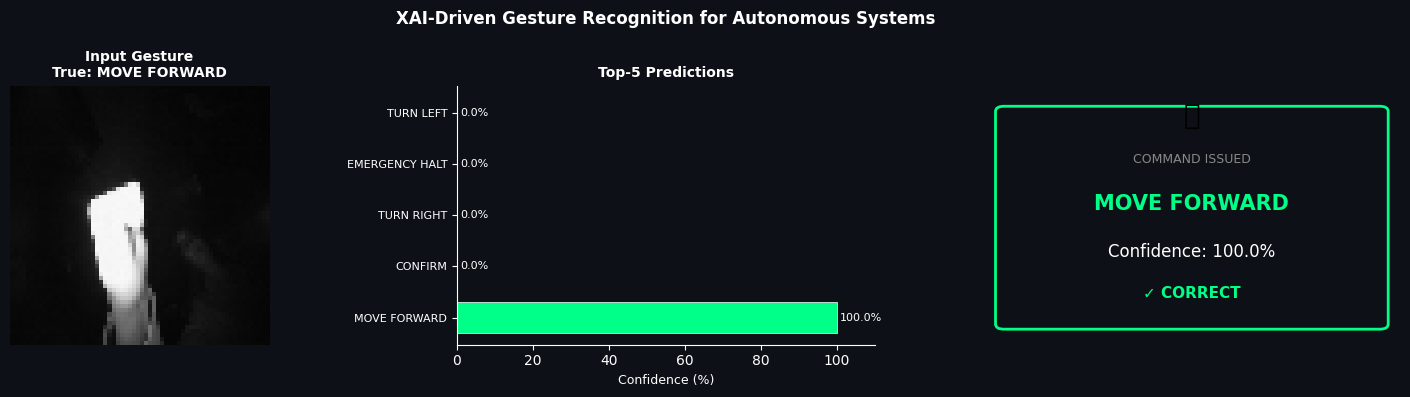

  04_fist_moved → MOVE FORWARD | 100.0% | ✓ CORRECT


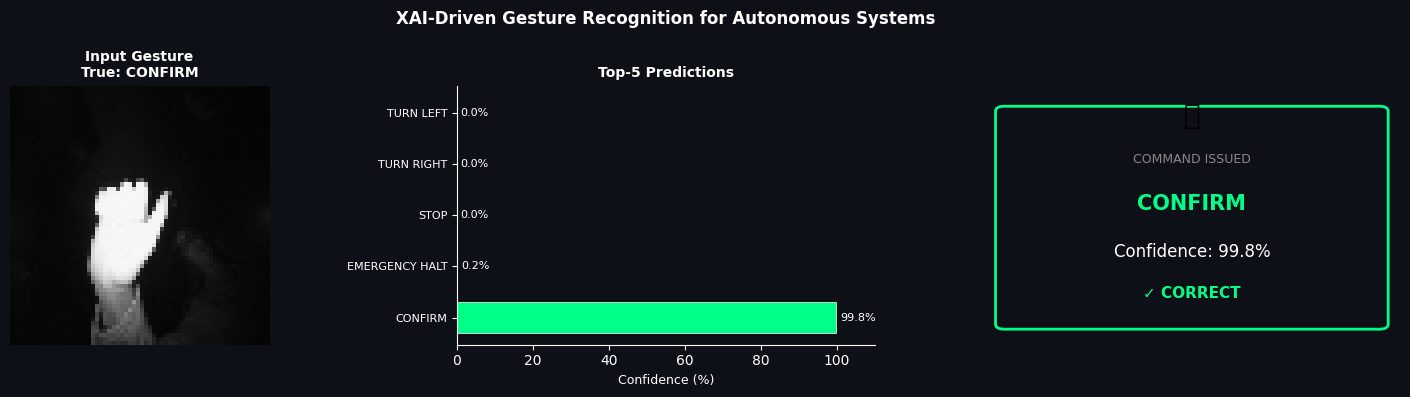

  05_thumb → CONFIRM | 99.8% | ✓ CORRECT


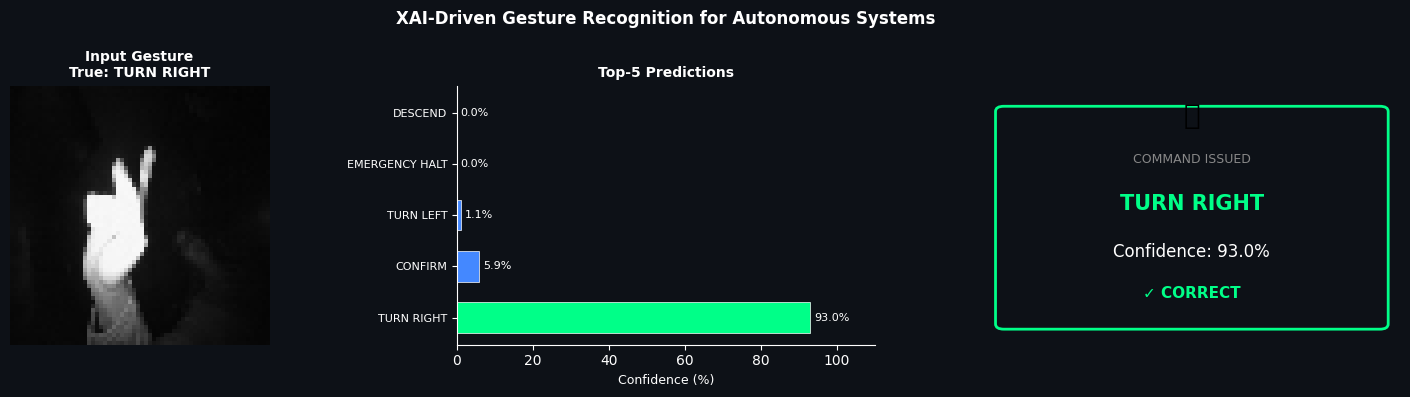

  06_index → TURN RIGHT | 93.0% | ✓ CORRECT


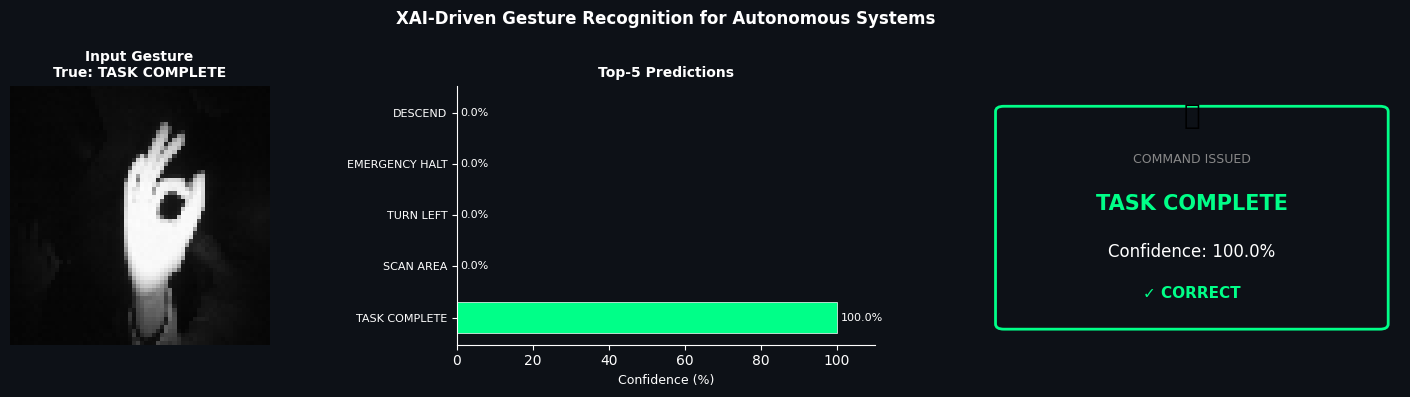

  07_ok → TASK COMPLETE | 100.0% | ✓ CORRECT


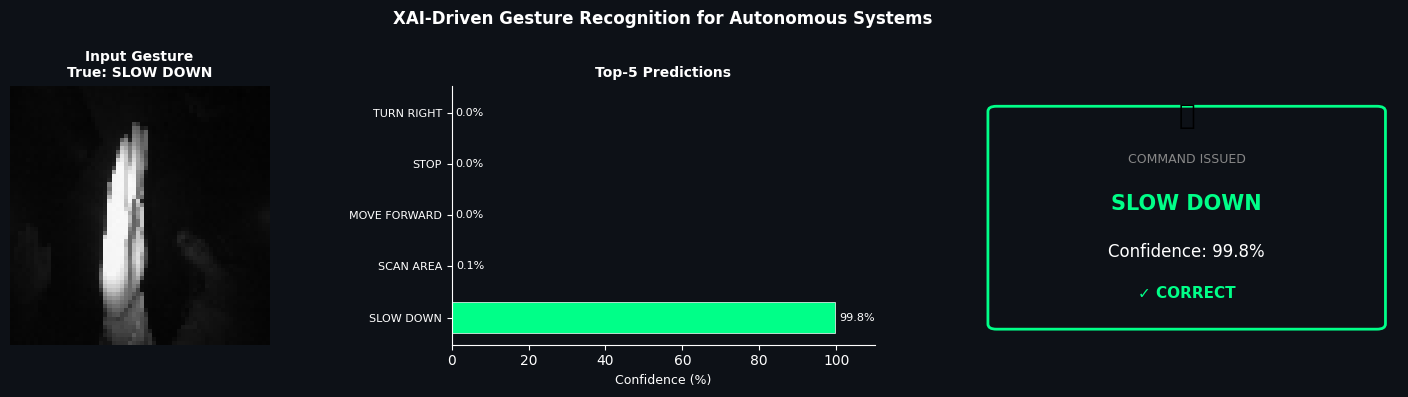

  08_palm_moved → SLOW DOWN | 99.8% | ✓ CORRECT


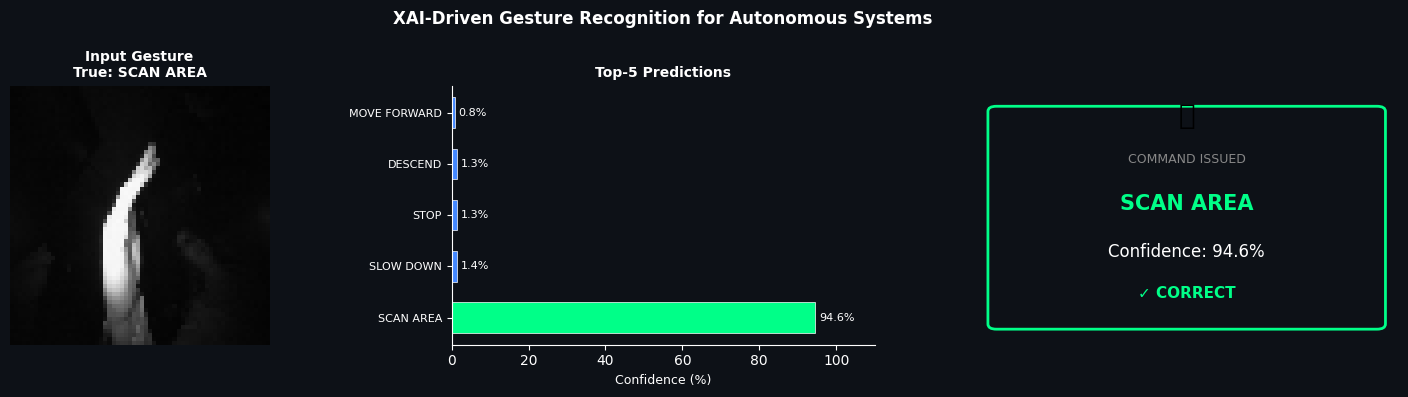

  09_c → SCAN AREA | 94.6% | ✓ CORRECT


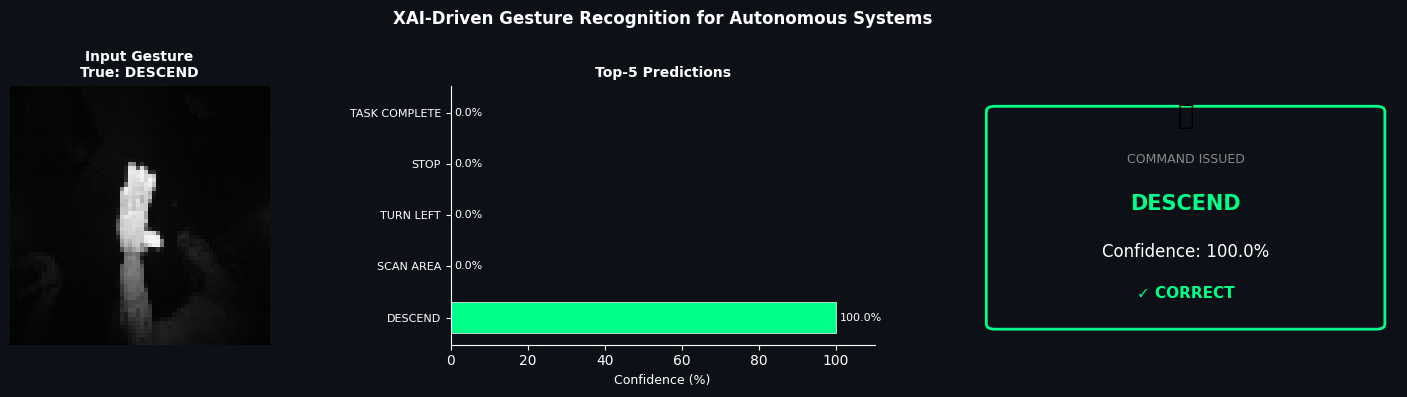

  10_down → DESCEND | 100.0% | ✓ CORRECT

 All 10 demos complete!


In [ ]:
import matplotlib.patches as mpatches

def autonomous_demo(model, image, true_label, sample_num):
    pred       = model.predict(image[np.newaxis], verbose=0)[0]
    pred_idx   = np.argmax(pred)
    pred_class = le.classes_[pred_idx]
    confidence = pred[pred_idx]
    command    = gesture_commands[pred_class]
    true_cmd   = gesture_commands[true_label]
    correct    = pred_class == true_label
    cam, _     = get_gradcam(model, image, pred_idx)

    top5_idx = np.argsort(pred)[::-1][:5]
    top5_cmd = [gesture_commands[le.classes_[j]] for j in top5_idx]
    top5_val = pred[top5_idx]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.patch.set_facecolor('#0d1117')
    for ax in axes:
        ax.set_facecolor('#0d1117')

    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'Input Gesture\nTrue: {true_cmd}',
                      fontsize=10, color='white', fontweight='bold')
    axes[0].axis('off')

    colors_bar = ['#00ff88' if j == pred_idx else '#4488ff'
                  for j in top5_idx]
    axes[1].barh(range(5), top5_val*100,
                 color=colors_bar, edgecolor='white',
                 linewidth=0.5, height=0.6)
    axes[1].set_yticks(range(5))
    axes[1].set_yticklabels(top5_cmd, fontsize=8, color='white')
    axes[1].set_xlabel('Confidence (%)', fontsize=9, color='white')
    axes[1].set_title('Top-5 Predictions', fontsize=10,
                      color='white', fontweight='bold')
    axes[1].tick_params(colors='white')
    for spine in ['bottom','left']:
        axes[1].spines[spine].set_color('white')
    for spine in ['top','right']:
        axes[1].spines[spine].set_visible(False)
    axes[1].set_xlim(0, 110)
    for bar, conf in zip(axes[1].patches, top5_val):
        axes[1].text(bar.get_width()+1,
                     bar.get_y()+bar.get_height()/2,
                     f'{conf*100:.1f}%',
                     va='center', fontsize=8, color='white')

    color  = '#00ff88' if correct else '#ff4444'
    status = '✓ CORRECT' if correct else '✗ INCORRECT'
    axes[2].text(0.5, 0.85, '🤖',
                 ha='center', fontsize=20,
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.70, 'COMMAND ISSUED',
                 ha='center', fontsize=9, color='#888888',
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.52, command,
                 ha='center', fontsize=15, fontweight='bold',
                 color=color, transform=axes[2].transAxes)
    axes[2].text(0.5, 0.34,
                 f'Confidence: {confidence*100:.1f}%',
                 ha='center', fontsize=12, color='white',
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.18, status,
                 ha='center', fontsize=11, color=color,
                 fontweight='bold', transform=axes[2].transAxes)
    fancy = mpatches.FancyBboxPatch(
        (0.05, 0.08), 0.9, 0.82,
        boxstyle="round,pad=0.02",
        linewidth=2, edgecolor=color, facecolor='none',
        transform=axes[2].transAxes)
    axes[2].add_patch(fancy)
    axes[2].axis('off')

    plt.suptitle(
        'XAI-Driven Gesture Recognition for Autonomous Systems',
        fontsize=12, fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig(f'demo_{sample_num}.png', dpi=150,
                bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    print(f"  {pred_class} → {command} | "
          f"{confidence*100:.1f}% | {status}")

print("Running Autonomous Command Demo...")
for i, cls in enumerate(le.classes_):
    idx = np.where(labels == cls)[0][0]
    autonomous_demo(mobilenet_model, images[idx], cls, i+1)
print("\n All 10 demos complete!")

Running Autonomous Command Demo...


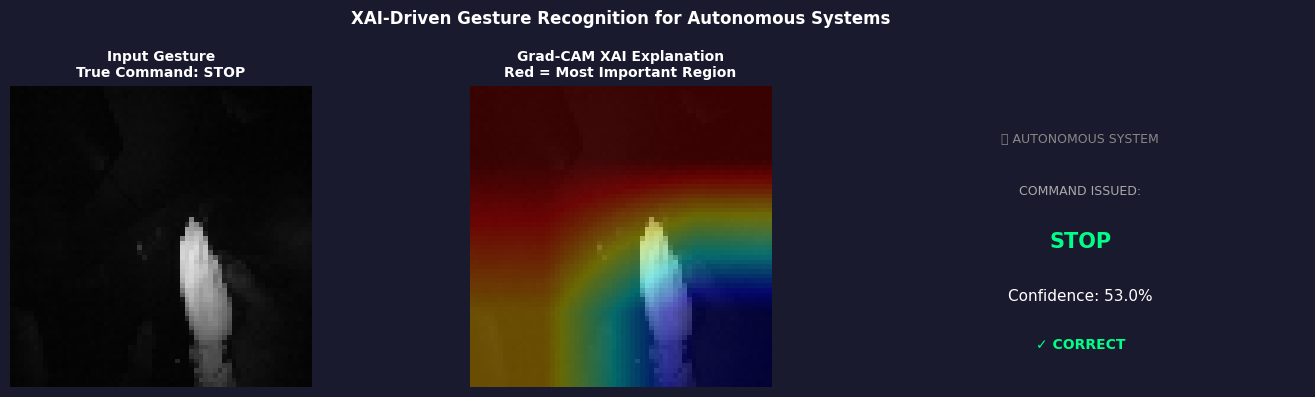

Sample 1: 01_palm → STOP | Confidence: 53.0% | ✓ CORRECT


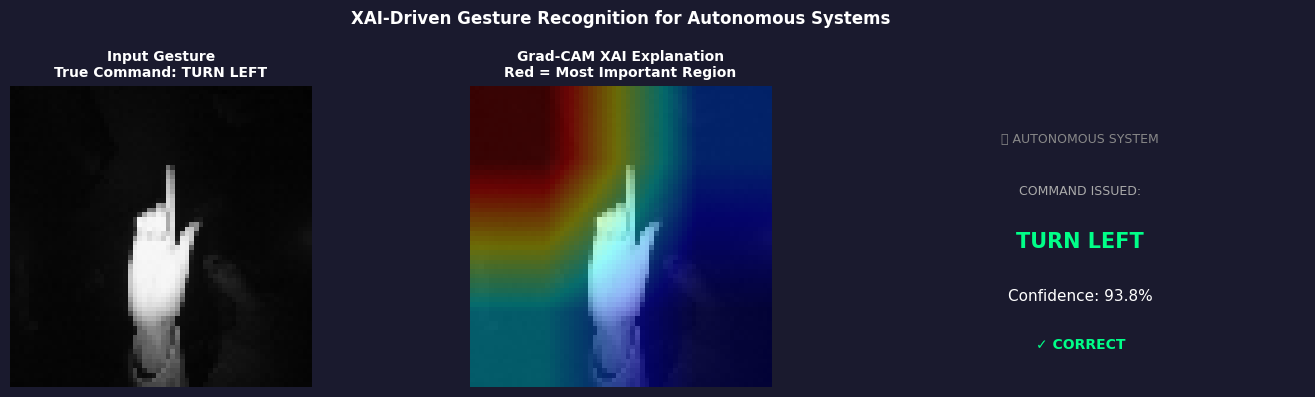

Sample 2: 02_l → TURN LEFT | Confidence: 93.8% | ✓ CORRECT


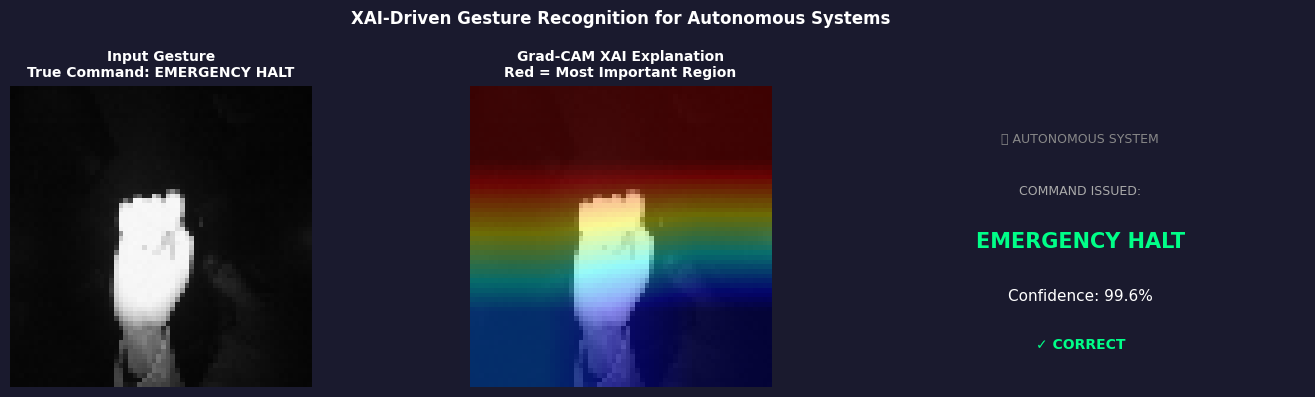

Sample 3: 03_fist → EMERGENCY HALT | Confidence: 99.6% | ✓ CORRECT


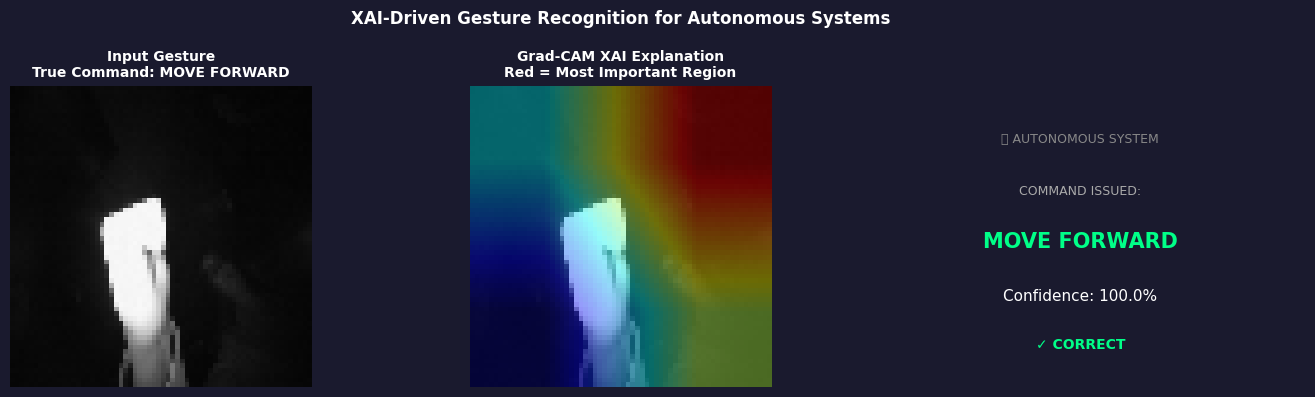

Sample 4: 04_fist_moved → MOVE FORWARD | Confidence: 100.0% | ✓ CORRECT


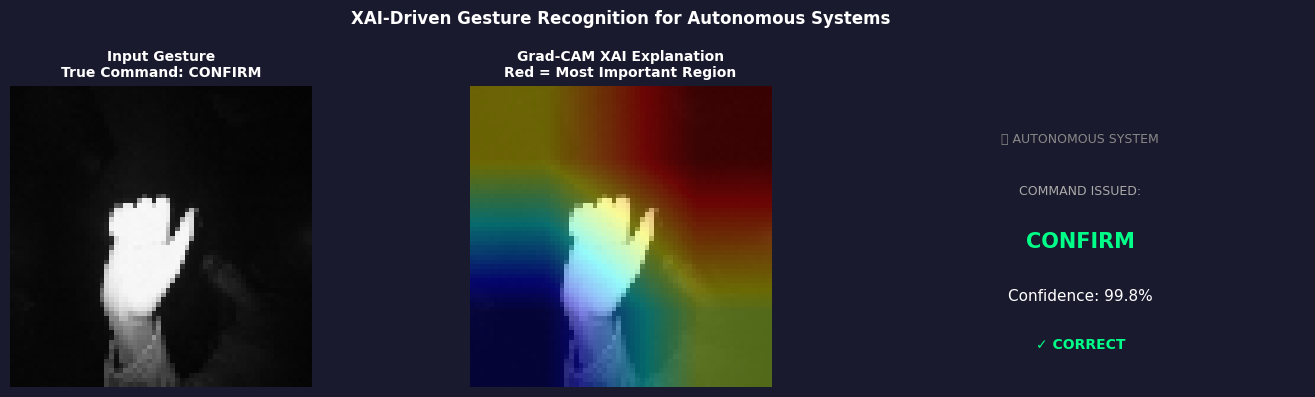

Sample 5: 05_thumb → CONFIRM | Confidence: 99.8% | ✓ CORRECT


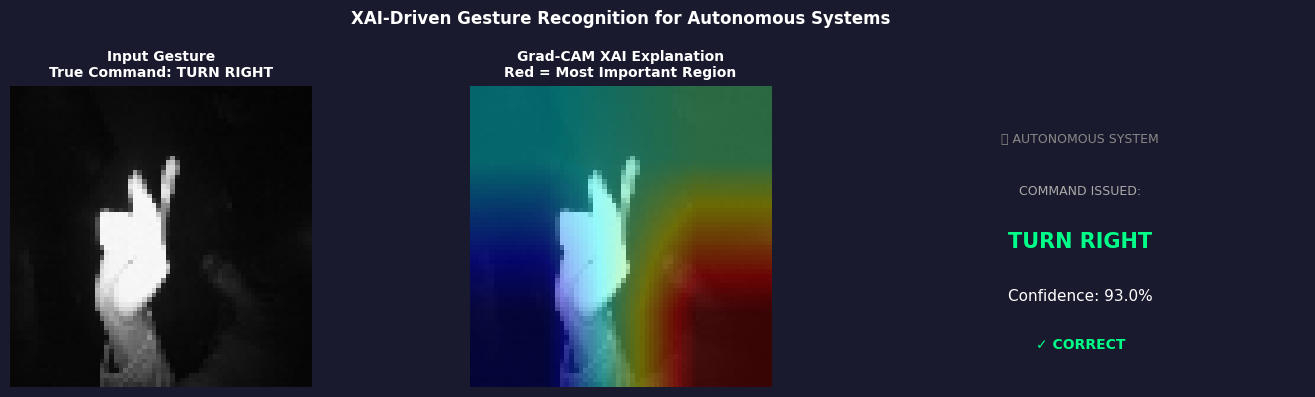

Sample 6: 06_index → TURN RIGHT | Confidence: 93.0% | ✓ CORRECT


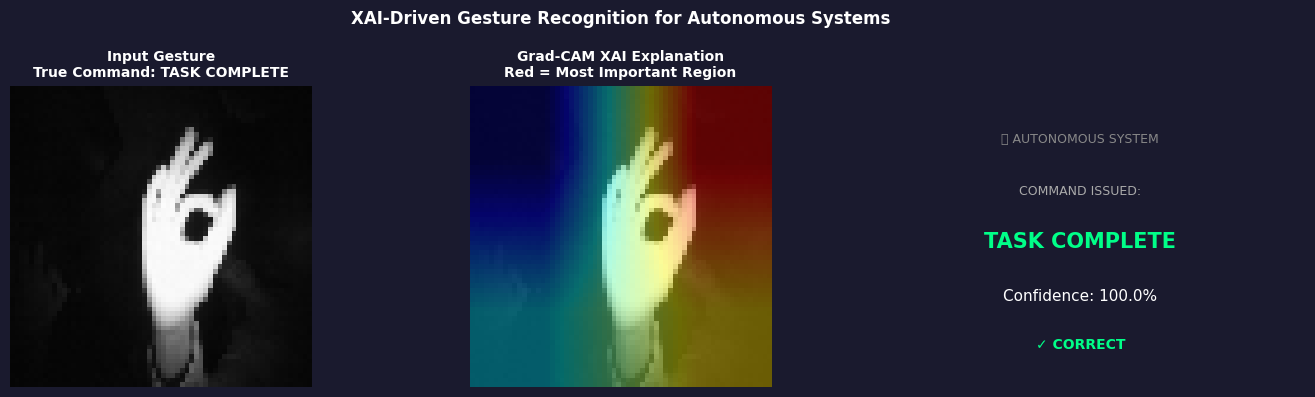

Sample 7: 07_ok → TASK COMPLETE | Confidence: 100.0% | ✓ CORRECT


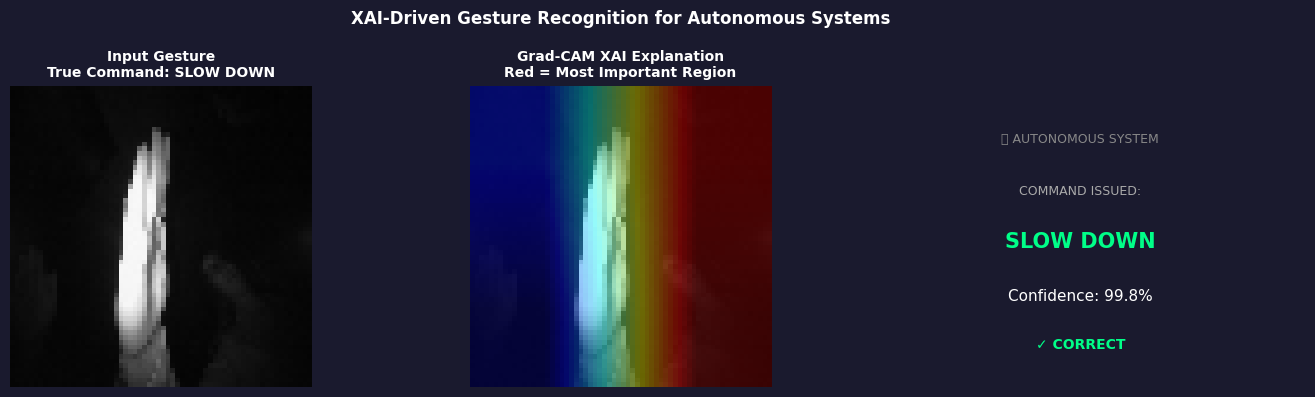

Sample 8: 08_palm_moved → SLOW DOWN | Confidence: 99.8% | ✓ CORRECT


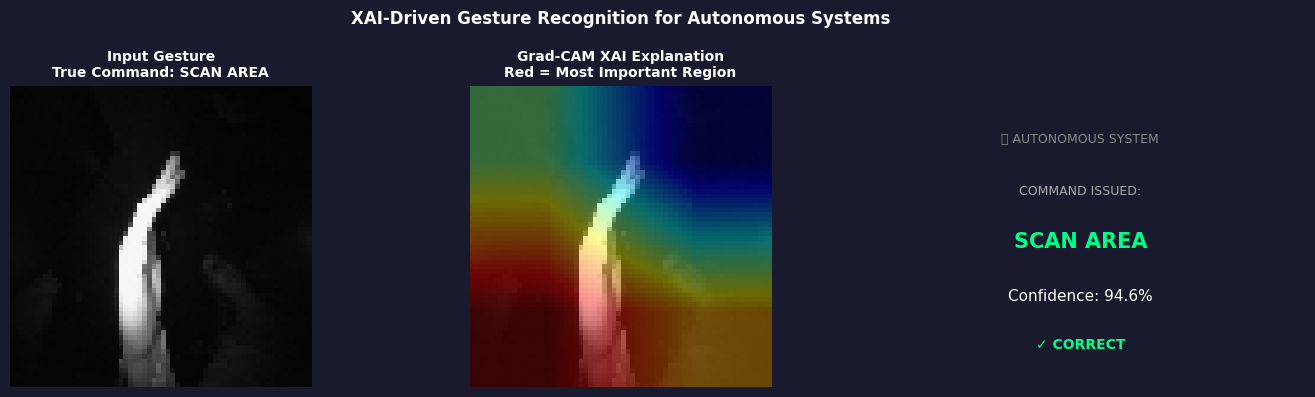

Sample 9: 09_c → SCAN AREA | Confidence: 94.6% | ✓ CORRECT


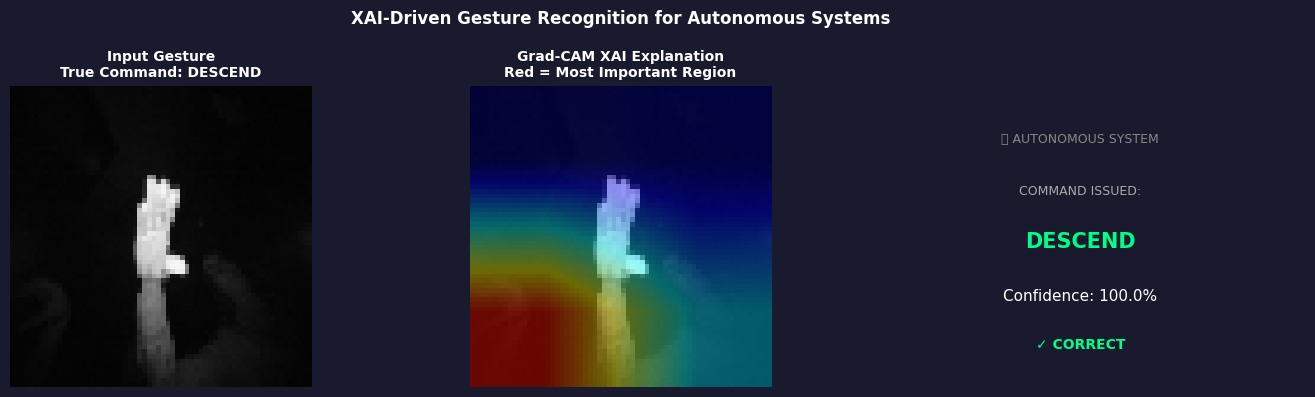

Sample 10: 10_down → DESCEND | Confidence: 100.0% | ✓ CORRECT


In [ ]:
def autonomous_command_demo(model, image, true_label, sample_num):
    pred       = model.predict(image[np.newaxis], verbose=0)[0]
    pred_idx   = np.argmax(pred)
    pred_class = le.classes_[pred_idx]
    confidence = pred[pred_idx]
    command    = gesture_commands[pred_class]
    true_cmd   = gesture_commands[true_label]
    cam, _     = get_gradcam(model, image, pred_idx)
    correct    = pred_class == true_label

    fig, axes  = plt.subplots(1, 3, figsize=(14, 4))
    fig.patch.set_facecolor('#1a1a2e')

    # Original gesture
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'Input Gesture\nTrue Command: {true_cmd}',
                      fontsize=10, color='white', fontweight='bold')
    axes[0].axis('off')
    axes[0].set_facecolor('#1a1a2e')

    # Grad-CAM
    axes[1].imshow(cv2.cvtColor(cam, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Grad-CAM XAI Explanation\nRed = Most Important Region',
                      fontsize=10, color='white', fontweight='bold')
    axes[1].axis('off')
    axes[1].set_facecolor('#1a1a2e')

    # Command output
    color = '#00ff88' if correct else '#ff4444'
    status = '✓ CORRECT' if correct else '✗ WRONG'
    axes[2].set_facecolor('#0d1117')
    axes[2].text(0.5, 0.82, '🤖 AUTONOMOUS SYSTEM',
                 ha='center', va='center', fontsize=9,
                 color='#888888', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.65, 'COMMAND ISSUED:',
                 ha='center', va='center', fontsize=9,
                 color='#aaaaaa', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.48, command,
                 ha='center', va='center', fontsize=15,
                 fontweight='bold', color=color,
                 transform=axes[2].transAxes)
    axes[2].text(0.5, 0.30,
                 f'Confidence: {confidence:.1%}',
                 ha='center', va='center', fontsize=11,
                 color='white', transform=axes[2].transAxes)
    axes[2].text(0.5, 0.14, status,
                 ha='center', va='center', fontsize=10,
                 color=color, fontweight='bold',
                 transform=axes[2].transAxes)
    axes[2].axis('off')

    plt.suptitle(
        'XAI-Driven Gesture Recognition for Autonomous Systems',
        fontsize=12, fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig(f'autonomous_demo_{sample_num}.png',
                dpi=150, facecolor='#1a1a2e')
    plt.show()
    print(f"Sample {sample_num}: {pred_class} → {command} "
          f"| Confidence: {confidence:.1%} | {status}")

# Demo on one sample per gesture class
print("Running Autonomous Command Demo...")
for i, cls in enumerate(le.classes_):
    idx = np.where(labels == cls)[0][0]
    autonomous_command_demo(
        mobilenet_model, images[idx], cls, i+1)

In [ ]:
import shutil

save_dir = '/content/drive/MyDrive/MTech_Project_Results'
os.makedirs(save_dir, exist_ok=True)

# Save models
mobilenet_model.save(f'{save_dir}/mobilenet_model.keras')
efficientnet_model.save(f'{save_dir}/efficientnet_model.keras')
print(" Models saved!")

files = [
    'dataset_samples.png',
    'training_results.png',
    'confusion_matrix.png',
    'gradcam_mobilenet.png',
    'gradcam_efficientnet.png',
    'lime_xai.png',
    'ig_mobilenet.png',
    'xai_metrics_table.png',
    'xai_metrics.csv',
    'model_comparison.csv',
    'mobilenet_gesture.tflite'
]

for f in files:
    if os.path.exists(f):
        shutil.copy(f, f'{save_dir}/{f}')
        print(f"   {f}")
    else:
        print(f"    Not found: {f}")

for i in range(1, 11):
    fname = f'demo_{i}.png'
    if os.path.exists(fname):
        shutil.copy(fname, f'{save_dir}/{fname}')
        print(f"   {fname}")

print(f"\n ALL SAVED → {save_dir}")

 Models saved!
   dataset_samples.png
   training_results.png
   confusion_matrix.png
   gradcam_mobilenet.png
    Not found: gradcam_efficientnet.png
   lime_xai.png
   ig_mobilenet.png
   xai_metrics_table.png
   xai_metrics.csv
   model_comparison.csv
   mobilenet_gesture.tflite
   demo_1.png
   demo_2.png
   demo_3.png
   demo_4.png
   demo_5.png
   demo_6.png
   demo_7.png
   demo_8.png
   demo_9.png
   demo_10.png

 ALL SAVED → /content/drive/MyDrive/MTech_Project_Results
